In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset('lukebarousse/data_jobs')

In [ ]:
df_clean_clean = dataset['train'].to_pandas()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Pandas:
##Inspecting

In [ ]:
df_clean.info()

NameError: name 'df_clean' is not defined

In [ ]:
df_clean.head()

In [ ]:
df_clean['job_title_short'].head(10)

In [ ]:
df_clean[['job_title_short', 'job_location']]

In [ ]:
df_clean.iloc[90]

In [ ]:
df_clean.iloc[90:100,0:2] #locate rows 90 - 100, rows 1,2

In [ ]:
df_clean.describe() # for numerical data, gives a quick snapshot

In [ ]:
df_clean.job_title_short.unique()

In [ ]:
df_clean.job_title_short == 'Data Analyst'

In [ ]:
df_clean[(df_clean.job_title_short == 'Data Analyst') & (df_clean.salary_year_avg > 100000)]

In [ ]:
df_clean.salary_year_avg.notna() # shows values without salaries

In [ ]:
df_clean[(df_clean.job_title_short == 'Data Analyst') & (df_clean.salary_year_avg.notna())]
# all the DA jobs with average salary where is not null.

##Cleaning

In [ ]:
df_clean.info()

In [ ]:
# job_posted_date is appearing as a string. confirm:
print(df_clean.job_posted_date[0])
print(type(df_clean.job_posted_date[0]))

In [ ]:
pd.to_datetime(df_clean.job_posted_date)

NameError: name 'df_clean' is not defined

In [ ]:
df_clean.info()

In [ ]:
df_clean['job_posted_date'] = pd.to_datetime(df_clean.job_posted_date)
# This re-assigns the column to itself in a new data type

In [ ]:
df_clean.info()

In [ ]:
# create a new column based on the job posting month.
df_clean['job_posted_month'] = df_clean.job_posted_date.dt.month

In [ ]:
df_clean.info()

In [ ]:
df_clean.sort_values('job_posted_date', inplace=True)
# to save the sorted data in the column we use 'inplace=True'

In [ ]:
# remove column salary_hour_avg
df_clean.drop(labels='salary_hour_avg', axis=1, inplace=True)

In [ ]:
df_clean.info()

In [ ]:
# drop rows in 'salary_year_acerage' that have null values. to save the new column we use 'inplace=True'
df_clean.dropna(subset=['salary_year_avg'], inplace=True)

In [ ]:
df_clean.info()

##Analyzing
Aggregating, grouping by

In [ ]:
# reload the dataset

In [ ]:
df = dataset['train'].to_pandas()

In [ ]:
# set the column 'job_posted_date' to datetime format again
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [ ]:
df.describe()

,job_posted_date,salary_year_avg,salary_hour_avg
count,785741,22003.000000,10662.000000
mean,2023-06-25 16:02:11.860248576,123286.274072,47.016598
min,2023-01-01 00:00:04,15000.000000,8.000000
25%,2023-03-20 10:05:48,90000.000000,27.500000
50%,2023-06-29 06:11:38,115000.000000,45.980000
75%,2023-09-27 01:01:16,150000.000000,61.159996
max,2023-12-31 23:59:58,960000.000000,391.000000
std,NaN,48312.449482,21.890738


In [ ]:
# 15 000 is the lowest salary which is extremely low! Let's investigate

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [ ]:
df['salary_year_avg'].median()

115000.0

In [ ]:
df['salary_year_avg'].min()

15000.0

In [ ]:
min_salary = df['salary_year_avg'].idxmin() # returns the row number of the minimum salary

In [ ]:
df.iloc[min_salary]
# using the iloc method, we can locate and pull the entire record from the dataframe for the min_salary

,665729
job_title_short,Data Engineer
job_title,Data Engineer - Hadoop
job_location,Brazil
job_via,via LinkedIn
job_schedule_type,Full-time
job_work_from_home,False
search_location,Brazil
job_posted_date,2023-12-09 10:05:30
job_no_degree_mention,True
job_health_insurance,False


In [ ]:
df['job_title_short'].value_counts()

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


In [ ]:
df.groupby('job_title_short')['salary_year_avg'].median()

,salary_year_avg
job_title_short,
Business Analyst,85000.0
Cloud Engineer,90000.0
Data Analyst,90000.0
Data Engineer,125000.0
Data Scientist,127500.0
Machine Learning Engineer,106415.0
Senior Data Analyst,111175.0
Senior Data Engineer,147500.0
Senior Data Scientist,155500.0


In [ ]:
df.groupby(['job_title_short', 'job_country'])['salary_year_avg'].median()

job_title_short    job_country
Business Analyst   Afghanistan        NaN
                   Albania            NaN
                   Algeria            NaN
                   Angola             NaN
                   Argentina      71100.0
                                   ...   
Software Engineer  Venezuela          NaN
                   Vietnam        53600.0
                   Yemen              NaN
                   Zambia             NaN
                   Zimbabwe           NaN
Name: salary_year_avg, Length: 1387, dtype: float64

In [ ]:
df.groupby('job_title_short')[['salary_year_avg', 'salary_hour_avg']].median()

,salary_year_avg,salary_hour_avg
job_title_short,,
Business Analyst,85000.0,40.362499
Cloud Engineer,90000.0,40.000000
Data Analyst,90000.0,32.615002
Data Engineer,125000.0,58.500000
Data Scientist,127500.0,47.500000
Machine Learning Engineer,106415.0,47.535000
Senior Data Analyst,111175.0,47.500000
Senior Data Engineer,147500.0,61.500000
Senior Data Scientist,155500.0,47.620003


In [ ]:
df.groupby('job_title_short')['salary_year_avg'].agg(['min','max','median'])

,min,max,median
job_title_short,,,
Business Analyst,16500.0,387460.0,85000.0
Cloud Engineer,42000.0,280000.0,90000.0
Data Analyst,25000.0,650000.0,90000.0
Data Engineer,15000.0,525000.0,125000.0
Data Scientist,27000.0,960000.0,127500.0
Machine Learning Engineer,30000.0,325000.0,106415.0
Senior Data Analyst,30000.0,425000.0,111175.0
Senior Data Engineer,35000.0,425000.0,147500.0
Senior Data Scientist,45000.0,890000.0,155500.0


In [ ]:
df['job_country'].value_counts().head(20)

,count
job_country,
United States,206292
India,51088
United Kingdom,40375
France,39922
Germany,27694
Spain,25100
Singapore,23696
Sudan,21781
Netherlands,20631


In [ ]:
df['job_country'].isin(['Sweden'])

,job_country
0,False
1,False
2,False
3,False
4,False
...,...
785736,False
785737,False
785738,False
785739,False


In [ ]:
df['job_country'].isin(['Sweden']).any()

np.True_

In [ ]:
us_jobs = df[df['job_country'] == 'United States']

In [ ]:
us_jobs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206292 entries, 0 to 785705
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        206292 non-null  object        
 1   job_title              206292 non-null  object        
 2   job_location           205505 non-null  object        
 3   job_via                206285 non-null  object        
 4   job_schedule_type      205099 non-null  object        
 5   job_work_from_home     206292 non-null  bool          
 6   search_location        206292 non-null  object        
 7   job_posted_date        206292 non-null  datetime64[ns]
 8   job_no_degree_mention  206292 non-null  bool          
 9   job_health_insurance   206292 non-null  bool          
 10  job_country            206292 non-null  object        
 11  salary_rate            25372 non-null   object        
 12  salary_year_avg        15766 non-null   float64  

In [ ]:
us_jobs = us_jobs[us_jobs['salary_year_avg'].notna()]
us_jobs

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"['sql', 'python']","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"['sql', 'r', 'python', 'express']","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"['python', 'r', 'alteryx', 'tableau']","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
116,Data Scientist,Data Scientist,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-10-04 13:04:23,False,False,United States,year,114000.0,NaN,4 Corner Resources,"['r', 'python', 'sql', 't-sql', 'hadoop', 'spa...","{'analyst_tools': ['tableau'], 'libraries': ['..."
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"['golang', 'scala', 'python', 'java', 'hadoop'...","{'libraries': ['hadoop', 'spark'], 'programmin..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785563,Data Scientist,Data Scientist I/II (Model Risk Management & M...,"Pensacola, FL",via Navy Federal Credit Union - Talentify,Full-time,False,"Florida, United States",2023-01-11 06:22:10,False,False,United States,year,136400.0,NaN,Navy Federal Credit Union,"['r', 'python', 'matplotlib', 'ggplot2', 'spar...","{'analyst_tools': ['word', 'power bi', 'tablea..."
785624,Data Engineer,Data Analytics Engineer (Hybrid),"Mt Prospect, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-08-31 06:02:16,False,True,United States,year,139216.0,NaN,Bosch Group,"['go', 'python', 'r', 'sql', 'oracle', 'window...","{'analyst_tools': ['alteryx', 'power bi', 'tab..."
785641,Data Engineer,Data Engineer,"New York, NY",via Dice,Full-time,False,Georgia,2023-01-04 16:36:07,True,False,United States,year,150000.0,NaN,"Engage Partners, Inc.",None,None
785648,Data Scientist,Director Data Scientist - Commercial Platforms...,"Pleasant Hill, CA",via Ai-Jobs.net,Full-time,False,"California, United States",2023-04-12 06:02:51,False,True,United States,year,221875.0,NaN,84.51°,"['python', 'azure', 'snowflake', 'spark']","{'cloud': ['azure', 'snowflake'], 'libraries':..."


In [ ]:
us_jobs.groupby('job_title_short')['salary_year_avg'].count()

,salary_year_avg
job_title_short,
Business Analyst,431
Cloud Engineer,20
Data Analyst,4350
Data Engineer,2915
Data Scientist,4553
Machine Learning Engineer,128
Senior Data Analyst,913
Senior Data Engineer,1058
Senior Data Scientist,1241


In [ ]:
us_jobs.groupby('job_title_short')['salary_year_avg'].min()

,salary_year_avg
job_title_short,
Business Analyst,35000.0
Cloud Engineer,42000.0
Data Analyst,25000.0
Data Engineer,23496.0
Data Scientist,30000.0
Machine Learning Engineer,44408.5
Senior Data Analyst,35360.0
Senior Data Engineer,45000.0
Senior Data Scientist,55000.0


In [ ]:
us_jobs.groupby('job_title_short')['salary_year_avg'].agg(['median', 'min', 'max', 'count'])

,median,min,max,count
job_title_short,,,,
Business Analyst,90000.0,35000.0,387460.0,431
Cloud Engineer,116100.0,42000.0,221844.0,20
Data Analyst,90000.0,25000.0,375000.0,4350
Data Engineer,125000.0,23496.0,525000.0,2915
Data Scientist,130000.0,30000.0,960000.0,4553
Machine Learning Engineer,150000.0,44408.5,315000.0,128
Senior Data Analyst,110000.0,35360.0,425000.0,913
Senior Data Engineer,150000.0,45000.0,375000.0,1058
Senior Data Scientist,155000.0,55000.0,475000.0,1241


In [ ]:
# sort values by median
us_jobs.groupby('job_title_short')['salary_year_avg'].agg(['median', 'min', 'max', 'count']).sort_values(by = 'median', ascending=False)

,median,min,max,count
job_title_short,,,,
Senior Data Scientist,155000.0,55000.0,475000.0,1241
Machine Learning Engineer,150000.0,44408.5,315000.0,128
Senior Data Engineer,150000.0,45000.0,375000.0,1058
Data Scientist,130000.0,30000.0,960000.0,4553
Software Engineer,130000.0,48982.0,375000.0,157
Data Engineer,125000.0,23496.0,525000.0,2915
Cloud Engineer,116100.0,42000.0,221844.0,20
Senior Data Analyst,110000.0,35360.0,425000.0,913
Business Analyst,90000.0,35000.0,387460.0,431


In [ ]:
# Filter on Swedish jobs


In [ ]:
swe_jobs = df[df['job_country'] == 'Sweden']
swe_jobs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6301 entries, 213 to 785680
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        6301 non-null   object        
 1   job_title              6301 non-null   object        
 2   job_location           6301 non-null   object        
 3   job_via                6301 non-null   object        
 4   job_schedule_type      6294 non-null   object        
 5   job_work_from_home     6301 non-null   bool          
 6   search_location        6301 non-null   object        
 7   job_posted_date        6301 non-null   datetime64[ns]
 8   job_no_degree_mention  6301 non-null   bool          
 9   job_health_insurance   6301 non-null   bool          
 10  job_country            6301 non-null   object        
 11  salary_rate            47 non-null     object        
 12  salary_year_avg        47 non-null     float64       
 13  sala

In [ ]:
swe_jobs = swe_jobs[swe_jobs['salary_year_avg'].notna()]
swe_jobs

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
2125,Business Analyst,Business Analyst to support Channel Engagement...,Sweden,via Ai-Jobs.net,Full-time,False,Sweden,2023-12-29 13:16:44,False,False,Sweden,year,43200.0,NaN,Nordea,['qlik'],{'analyst_tools': ['qlik']}
8965,Data Scientist,"Data Scientist, Marketing Analytics","Stockholm, Sweden",via Ai-Jobs.net,Full-time,False,Sweden,2023-02-14 13:35:13,False,False,Sweden,year,157500.0,NaN,Dun & Bradstreet,"['r', 'python', 'julia', 'redshift', 'databric...","{'analyst_tools': ['tableau', 'power bi'], 'cl..."
11617,Data Scientist,Data Scientist to Retail Space Planning & Anal...,"Stockholm, Sweden",via Ai-Jobs.net,Full-time,False,Sweden,2023-02-11 13:21:38,False,False,Sweden,year,157500.0,NaN,H&M Group,"['r', 'python', 'sql', 'gdpr']","{'libraries': ['gdpr'], 'programming': ['r', '..."
15699,Senior Data Analyst,Senior Business Data Analyst - BA HEAT,"Stockholm, Sweden",via Ai-Jobs.net,Full-time,False,Sweden,2023-01-25 14:08:43,False,False,Sweden,year,49566.5,NaN,Vattenfall,['azure'],{'cloud': ['azure']}
22635,Data Engineer,Data Engineer [Game Intelligence],"Malmö, Sweden",via Ai-Jobs.net,Full-time,False,Sweden,2023-07-03 13:26:00,False,False,Sweden,year,134241.0,NaN,Ubisoft,"['assembly', 'python', 'sql', 'airflow', 'gdpr...","{'analyst_tools': ['tableau'], 'libraries': ['..."
30726,Senior Data Engineer,Senior Data Engineer,"Solna, Sweden",via Ai-Jobs.net,Full-time,False,Sweden,2023-06-14 13:18:17,False,False,Sweden,year,147500.0,NaN,Vattenfall,"['sql', 'azure', 'power bi']","{'analyst_tools': ['power bi'], 'cloud': ['azu..."
104181,Business Analyst,Manufacturing Business Intelligence Lead,Sweden,via Ai-Jobs.net,Full-time,False,Sweden,2023-12-24 00:13:48,True,False,Sweden,year,86400.0,NaN,Volvo Group,"['python', 'snowflake', 'power bi', 'tableau']","{'analyst_tools': ['power bi', 'tableau'], 'cl..."
116067,Data Analyst,Data Analyst - Product & Engineering Tech Cent...,"Stockholm, Sweden",via Ai-Jobs.net,Full-time,False,Sweden,2023-07-11 08:57:26,True,False,Sweden,year,100500.0,NaN,H&M Group,"['sql', 'python', 'gdpr']","{'libraries': ['gdpr'], 'programming': ['sql',..."
142060,Data Scientist,"Senior Analytics Engineer (Stockholm, Sweden)","Stockholm, Sweden",via Ai-Jobs.net,Full-time,False,Sweden,2023-02-17 08:42:19,True,False,Sweden,year,81000.0,NaN,Datatonic,"['sql', 'snowflake', 'bigquery', 'airflow', 'l...","{'analyst_tools': ['looker'], 'cloud': ['snowf..."
143440,Senior Data Scientist,Senior Analytics Engineer (Multiple domains),"Stockholm, Sweden",via Ai-Jobs.net,Full-time,False,Sweden,2023-07-15 08:24:38,False,False,Sweden,year,147500.0,NaN,Wolt,"['python', 'sql', 'snowflake', 'aws', 'airflow...","{'analyst_tools': ['looker', 'tableau', 'power..."


In [ ]:
swe_jobs.count()

,0
job_title_short,47
job_title,47
job_location,47
job_via,47
job_schedule_type,47
job_work_from_home,47
search_location,47
job_posted_date,47
job_no_degree_mention,47
job_health_insurance,47


In [ ]:
swe_jobs.groupby('job_title_short')['salary_year_avg'].count()

,salary_year_avg
job_title_short,
Business Analyst,7
Data Analyst,9
Data Engineer,8
Data Scientist,7
Machine Learning Engineer,3
Senior Data Analyst,3
Senior Data Engineer,6
Senior Data Scientist,3
Software Engineer,1


In [ ]:
# sort values by median salary descending
swe_jobs.groupby('job_title_short')['salary_year_avg'].agg(['median', 'min', 'max', 'count']).sort_values(by = 'median', ascending=False)

,median,min,max,count
job_title_short,,,,
Senior Data Scientist,170500.0,147500.0,192000.0,3
Data Scientist,157500.0,81000.0,157500.0,7
Software Engineer,156500.0,156500.0,156500.0,1
Senior Data Engineer,147500.0,147500.0,147500.0,6
Machine Learning Engineer,141000.0,80850.0,166000.0,3
Data Engineer,133870.5,60000.0,249000.0,8
Senior Data Analyst,111175.0,49566.5,111175.0,3
Data Analyst,105650.0,45000.0,118140.0,9
Business Analyst,89100.0,43200.0,123500.0,7


#Matplotlib.PyPlot

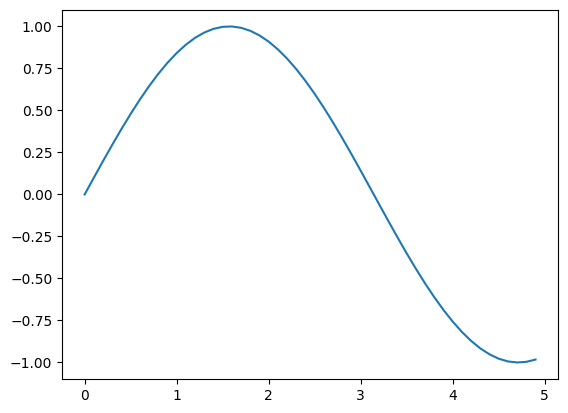

In [ ]:
x = np.arange(0, 5, 0.1)
y = np.sin(x)
plt.plot(x,y)

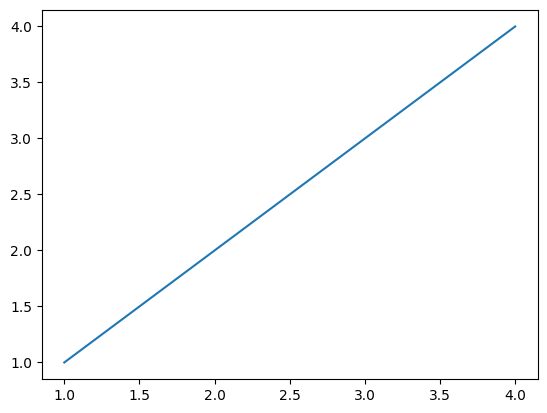

In [ ]:
x = [1,2,3,4]
y = [1,2,3,4]
plt.plot(x,y)

In [ ]:
df.job_posted_date.head()

,job_posted_date
0,2023-06-16 13:44:15
1,2023-01-14 13:18:07
2,2023-10-10 13:14:55
3,2023-07-04 13:01:41
4,2023-08-07 14:29:36


In [ ]:
df.job_posted_date.value_counts()

,count
job_posted_date,
2023-08-24 11:35:33,10
2023-01-01 23:37:09,10
2023-01-01 14:07:23,10
2023-11-09 09:02:12,10
2023-06-20 17:19:57,10
...,...
2023-06-08 07:43:38,1
2023-01-12 06:12:32,1
2023-10-16 06:01:53,1


In [ ]:
date_counts = df.job_posted_date.value_counts()

In [ ]:
date_counts = date_counts.sort_index()

In [ ]:
type(date_counts)
# no longer a dataframe

pandas.core.series.Series

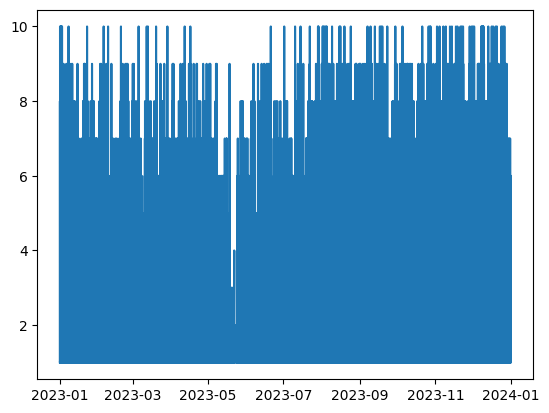

In [ ]:
plt.plot(date_counts.index, date_counts)

In [ ]:
df['job_posted_month'] = df['job_posted_date'].dt.month

In [ ]:
monthly_counts = df.job_posted_month.value_counts()
monthly_counts = monthly_counts.sort_index()
monthly_counts

,count
job_posted_month,
1,91822
2,64578
3,64084
4,62919
5,52104
6,61572
7,63777
8,75162
9,62359


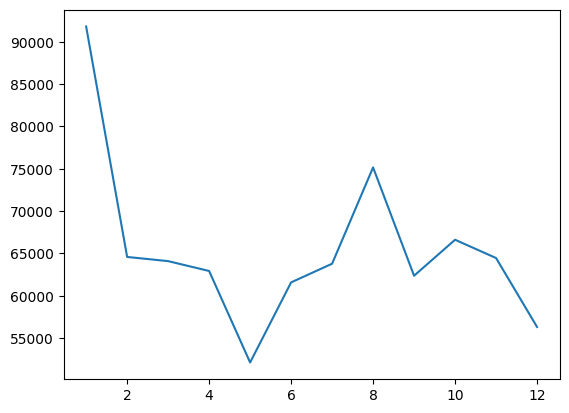

In [ ]:
plt.plot(monthly_counts.index, monthly_counts.values)

In [ ]:
series = pd.Series([10,20,30,40,50], index = ['a','b','c','d','e'])

In [ ]:
series.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')

In [ ]:
series.values

array([10, 20, 30, 40, 50])

#Bar Charts
Counts of Job Postings

In [ ]:
df.job_title_short.value_counts()

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


In [ ]:
job_counts = df.job_title_short.value_counts()

<BarContainer object of 10 artists>

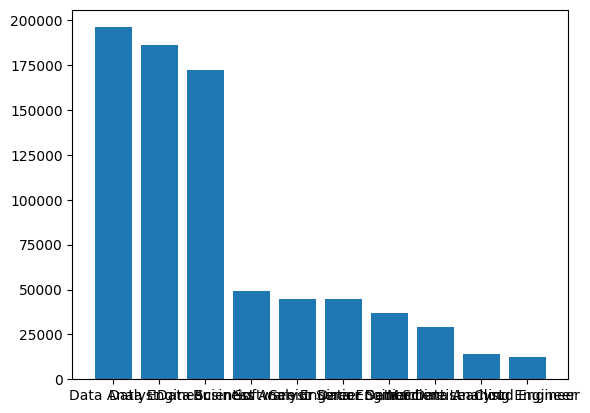

In [ ]:
plt.bar(job_counts.index, job_counts)

<BarContainer object of 10 artists>

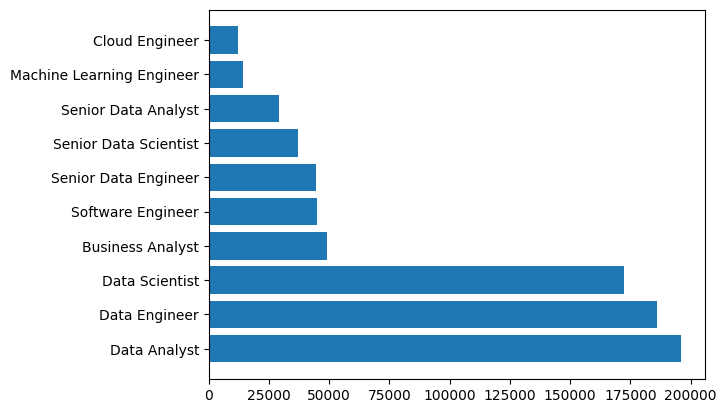

In [ ]:
plt.barh(job_counts.index, job_counts)

<BarContainer object of 10 artists>

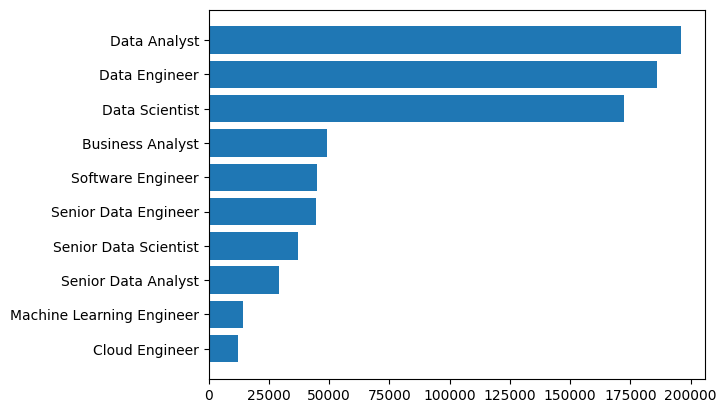

In [ ]:
job_counts = job_counts.sort_values(ascending=True)
plt.barh(job_counts.index, job_counts)

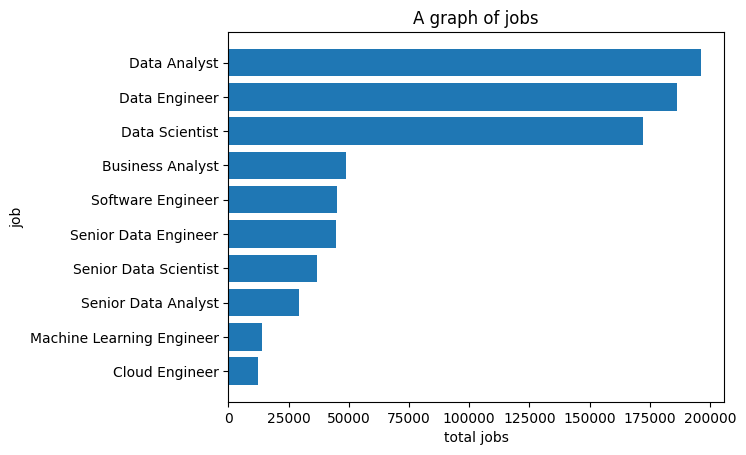

In [ ]:
plt.barh(job_counts.index, job_counts)
plt.xlabel('total jobs') # Corrected: call xlabel as a function
plt.ylabel('job') # Corrected: call ylabel as a function
plt.title('A graph of jobs') # Corrected: call title as a function
plt.show()

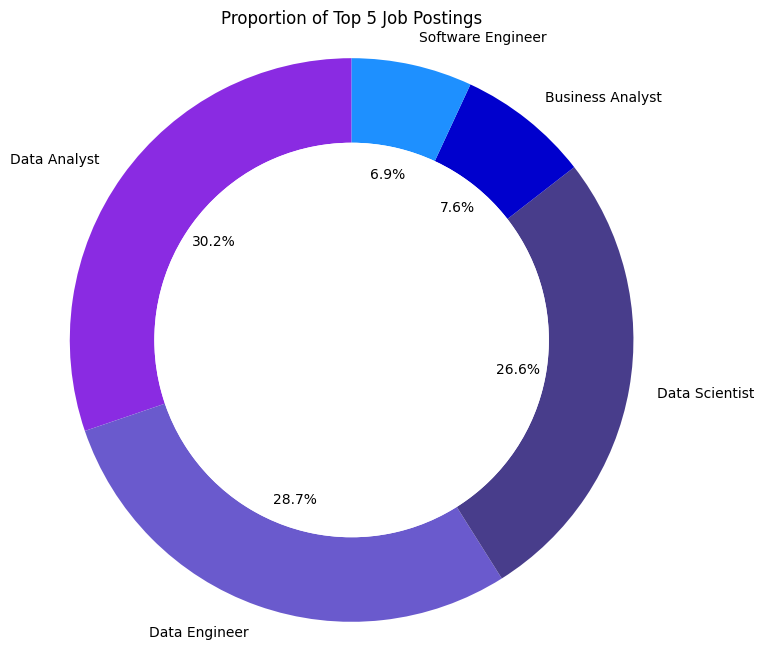

In [ ]:
import matplotlib.pyplot as plt

# Get the top 5 job titles by count
top_jobs = df['job_title_short'].value_counts().head(5)

# Define colors (shades of blue and purple)
colors = ['#8A2BE2', '#6A5ACD', '#483D8B', '#0000CD', '#1E90FF'] # Dark Orchid, Slate Blue, Dark Slate Blue, Medium Blue, Dodger Blue

# Create the pie chart (donut chart)
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(top_jobs,
                                   labels=top_jobs.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors,
                                   wedgeprops=dict(width=0.3) # This creates the donut effect
                                  )

# Draw a circle in the center to make it a donut chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')
plt.title("Proportion of Top 5 Job Postings")
plt.show()

In [ ]:
job_counts

,count
job_title_short,
Cloud Engineer,12331
Machine Learning Engineer,14080
Senior Data Analyst,29216
Senior Data Scientist,36957
Senior Data Engineer,44563
Software Engineer,44929
Business Analyst,49063
Data Scientist,172286
Data Engineer,186241


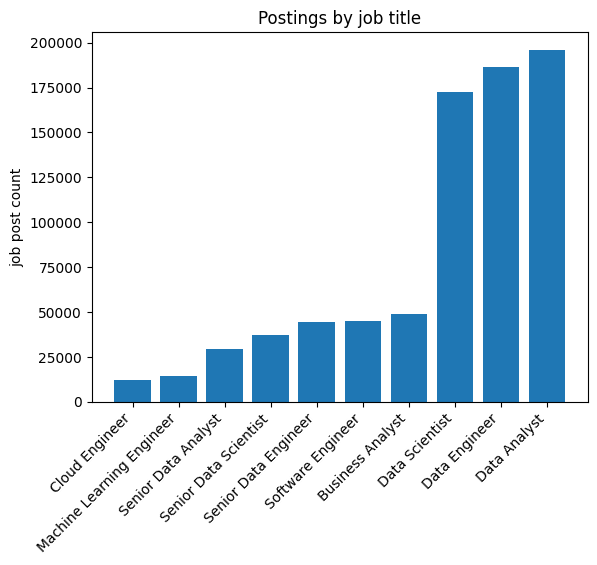

In [ ]:
import matplotlib.pyplot as plt # Re-import to restore overwritten functions

plt.bar(job_counts.index, job_counts)
plt.title('Postings by job title')
plt.ylabel("job post count")
plt.xticks(rotation=45, ha='right')
plt.show()

##Matplotlib and Pandas             

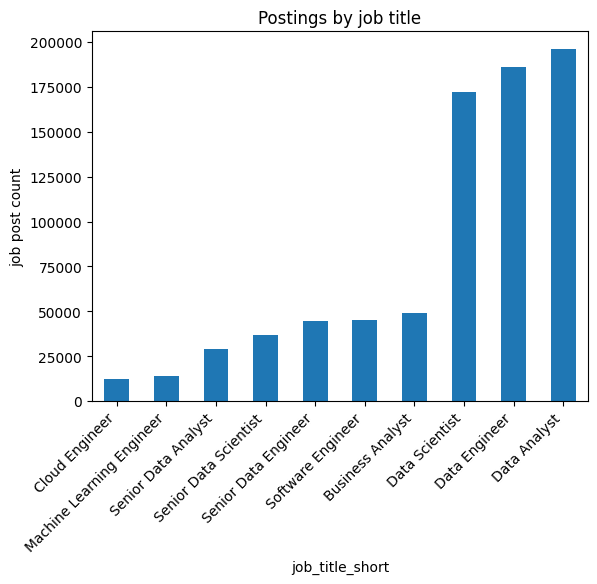

In [ ]:
job_counts.plot(kind='bar')

plt.ylabel("job post count")
plt.title('Postings by job title')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# how is the salary changing over time in the year 2023?
df.plot(x='job_posted_date', y='salary_year_avg', kind='bar')

NameError: name 'df' is not defined

##Median Salary Vs Data Science Jobs

In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [7]:
# we want to agregate the job titles and group them
df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

,salary_year_avg
job_title_short,
Business Analyst,85000.0
Cloud Engineer,90000.0
Data Analyst,90000.0
Software Engineer,99150.0
Machine Learning Engineer,106415.0
Senior Data Analyst,111175.0
Data Engineer,125000.0
Data Scientist,127500.0
Senior Data Engineer,147500.0


In [11]:
job_salary =   df.groupby('job_title_short')['salary_year_avg'].mean().sort_values()
# once this is converted to a series, it can be plotted

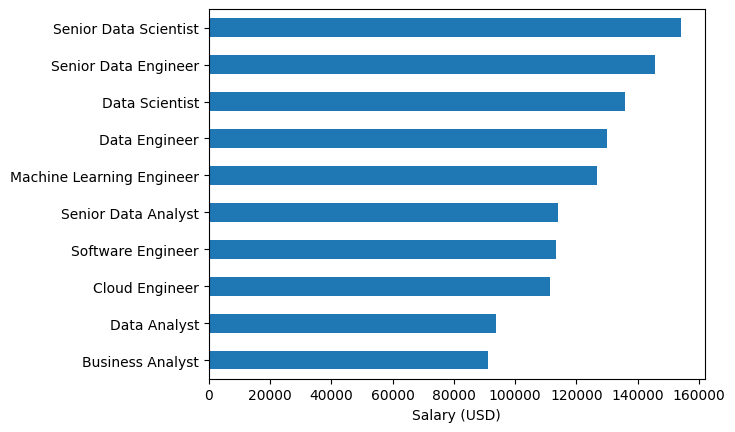

In [14]:
job_salary.plot(kind='barh')
plt.xlabel('Salary (USD)')
plt.ylabel('') #can remove unnecessary labels w/ ('')
plt.show()